# 🦄 🔮 Under The Hood - Recap

## 📚 Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

## 👩🏿‍⚕️ Dataset

In [3]:
X, y = datasets.load_diabetes(return_X_y = True, as_frame = True)

print(X.shape)
print(y.shape)

(442, 10)
(442,)


In [4]:
X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


⚠️ X is ALREADY SCALED!!!

In [5]:
y.head()

0    151.0
1     75.0
2    141.0
3    206.0
4    135.0
Name: target, dtype: float64

## ⛷️ Gradient Descent (with NumPy and Matrix Multiplication)

### TRAIN

In [6]:
X["fake"] = 1
X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,fake
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,1
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,1
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,1
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,1
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,1


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X,y)

In [8]:
X_train.shape

(331, 11)


Let's recall the definition of the gradient descent algorithm

$$\text{Gradient descent - vector formula}$$
$$\beta^{\color {red}{(k+1)}} = \beta^{\color {red}{(k)}} - \eta \ \nabla L(\beta^{\color{red}{(k)}})$$

The MSE Loss for an OLS regression is

$$L(\beta) = \frac{1}{n}\|y - X \beta\|^2 = \frac{1}{n}(y - X \beta)^T(y - X \beta )$$

and its gradient is
$${\displaystyle \nabla L(\beta)=
{\begin{bmatrix}{\frac {\partial L}{\partial \beta_{0}}}(\beta)\\\vdots \\{\frac {\partial L}{\partial \beta_{p}}}(\beta)\end{bmatrix}} = \frac{2}{n} X^T (y - X \beta) 
}$$

In [9]:
# Number of observations
n = X.shape[0]
n_train = X_train.shape[0]
n_test = X_test.shape[0]

n, n_train, n_test

(442, 331, 111)

In [10]:
nb_coeff = X.shape[1]
nb_coeff

11

In [11]:
# Gradient Descent Hyper parameters
learning_rate = 0.10 
n_epochs = 100

In [12]:
##########################
# GRADIENT DESCENT V2    #
##########################

# 1 - Initialize randomly (10 coeff + 1 intercept)
betas = np.zeros(nb_coeff)
betas

# 2 - GD
for epoch in range(n_epochs):
    predictions_train = np.dot(X_train, betas)
    errors_train = y_train - predictions_train
    gradient = -(2/n_train) * np.dot(X_train.T, errors_train)
    betas = betas - learning_rate * gradient

# 3 - betas
print(f"best betas = {betas}")

best betas = [ 14.27001212   2.83809525  41.48267844  32.40785265  13.33338048
  10.72539521 -28.27924325  30.45206285  40.12839917  27.0869864
 153.59198487]


### MSE

In [13]:
predictions_test = np.dot(X_test, betas)

In [14]:
mse_train = mean_squared_error(y_train, predictions_train)
mse_test = mean_squared_error(y_test, predictions_test)

In [15]:
mse_train, mse_test

(5339.618174289268, 4933.448853250483)

### `my_gradient_descent`

In [16]:
def my_gradient_descent(X_train, y_train, X_test, y_test, learning_rate = 0.01, n_epochs=100):
    # Parameters
    n_train = X_train.shape[0]
    n_test = X_test.shape[0]
    nb_coeff = X_train.shape[1]
        # Here, we assume that there is a "fake" column of ones
    # to be multiplied with beta0 (the intercept)
    # Initialize betas "randomly"
    betas = np.zeros(nb_coeff)
    # Saving
    loss_train_history = []
    loss_test_history = []
    # GD
    for epoch in range(n_epochs):
        ### Compute Gradient
        predictions_train = np.dot(X_train, betas)
        errors_train = y_train - predictions_train
        gradient = -(2/n_train) * np.dot(X_train.T, errors_train)
        betas = betas - learning_rate * gradient
        ### Compute errors
        ###### MSE TRAIN
        predictions_train = np.dot(X_train, betas)
        errors_train = y_train - predictions_train
        mse_train = (1/n_train)*np.dot(errors_train.T, errors_train)
        loss_train_history.append(mse_train)
        ###### MSE TEST
        predictions_test = np.dot(X_test, betas)
        errors_test = y_test - predictions_test
        mse_test = (1/n_test)*np.dot(errors_test.T, errors_test)        
        loss_test_history.append(mse_test)        
    return betas, loss_train_history, loss_test_history

In [17]:
%%time
betas, loss_train_history, loss_test_history = my_gradient_descent(X_train, y_train, X_test, y_test, learning_rate = 0.01, n_epochs=100)

CPU times: user 25 ms, sys: 1.68 ms, total: 26.7 ms
Wall time: 25.7 ms


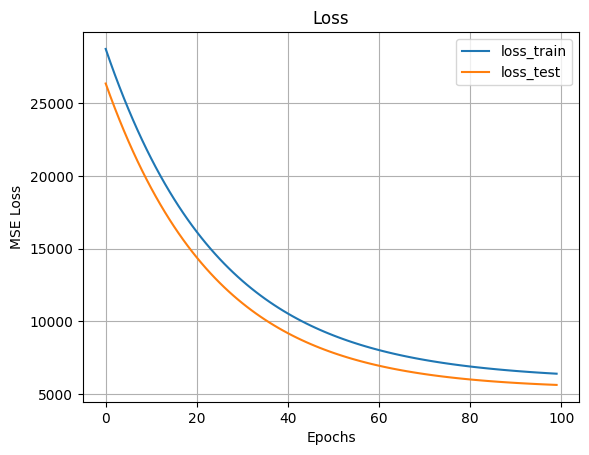

In [18]:
plt.plot(loss_train_history, label="loss_train")
plt.plot(loss_test_history, label="loss_test")

# Set title and labels
plt.title('Loss')
plt.ylabel('MSE Loss')
plt.xlabel('Epochs')
plt.grid()
plt.legend()
plt.show()

## ⏯️ 🛑 Early Stopping before Overfitting !

In [19]:
def my_gradient_descent_early_stopping_one_patience(X_train, y_train, X_test, y_test, learning_rate = 0.01, n_epochs=100):
    # Parameters
    n_train = X_train.shape[0]
    n_test = X_test.shape[0]
    nb_coeff = X_train.shape[1]
    # Initialize betas "randomly"
    betas = np.zeros(nb_coeff)
    # Saving
    loss_train_history = []
    loss_test_history = []
    # GD
    for epoch in range(n_epochs):
        ### Compute Gradient
        predictions_train = np.dot(X_train, betas)
        errors_train = y_train - predictions_train
        gradient = -(2/n_train) * np.dot(X_train.T, errors_train)
        betas = betas - learning_rate * gradient
        ### Compute errors
        ###### MSE TRAIN
        predictions_train = np.dot(X_train, betas)
        errors_train = y_train - predictions_train
        mse_train = (1/n_train)*np.dot(errors_train.T, errors_train)
        loss_train_history.append(mse_train)
        ###### MSE TEST
        predictions_test = np.dot(X_test, betas)
        errors_test = y_test - predictions_test
        mse_test = (1/n_test)*np.dot(errors_test.T, errors_test)        
        loss_test_history.append(mse_test)
        ### EARLY STOPPING?
        if epoch > 0 and mse_test > loss_test_history[-2]:
            break
    return betas, loss_train_history, loss_test_history

## 🥋 Mini-Batch Gradient Descent

In [20]:
np.random.permutation(10)

array([7, 6, 9, 2, 3, 4, 5, 0, 8, 1])

In [21]:
np.random.permutation(10)

array([8, 4, 9, 6, 3, 1, 0, 7, 5, 2])

In [22]:
np.random.permutation(10)

array([3, 7, 1, 6, 0, 4, 5, 9, 8, 2])

In [23]:
np.random.permutation(10)

array([3, 4, 6, 8, 0, 2, 1, 9, 5, 7])

In [24]:
X_train.shape

(331, 11)

In [25]:
for i in range(0,331,32):
    print(i)

0
32
64
96
128
160
192
224
256
288
320


In [26]:
def mini_batch_gradient_descent(X_train, y_train, X_test, y_test, learning_rate = 0.1, n_epochs=100, batch_size=8):
    # parameters
    n_train = X_train.shape[0]
    n_test = X_test.shape[0]
    nb_coeff = X_train.shape[1]
    # Initialize betas "randomly"
    betas = np.zeros(nb_coeff)
    # Saving
    loss_train_history = []
    loss_test_history = []
    # GD
    for epoch in range(n_epochs):
        # SHUFFLING X_train
        random_indices = np.random.permutation(n_train)
        X_train_tmp = X_train.iloc[random_indices]
        y_train_tmp = y_train.iloc[random_indices]
        # ITERATIONS BATCH 
        for i in range(0, n_train, batch_size):
            if i+batch_size <= n_train:
                X_mini = X_train_tmp.iloc[i:i+batch_size]
                y_mini = y_train_tmp.iloc[i:i+batch_size] 
            else:
                X_mini = X_train_tmp.iloc[i:]
                y_mini = y_train_tmp.iloc[i:]
            ### Compute Gradient
            predictions_mini = np.dot(X_mini, betas)
            errors_mini = y_mini - predictions_mini
            gradient = -(2/X_mini.shape[0]) * np.dot(X_mini.T, errors_mini)
            betas = betas - learning_rate * gradient
            
        ### Compute errors
        ###### MSE TRAIN
        predictions_train = np.dot(X_train, betas)
        errors_train = y_train - predictions_train
        mse_train = (1/n_train)*np.dot(errors_train.T, errors_train)
        loss_train_history.append(mse_train)
        ###### MSE TEST
        predictions_test = np.dot(X_test, betas)
        errors_test = y_test - predictions_test
        mse_test = (1/n_test)*np.dot(errors_test.T, errors_test)        
        loss_test_history.append(mse_test)    
    
    return betas, loss_train_history, loss_test_history

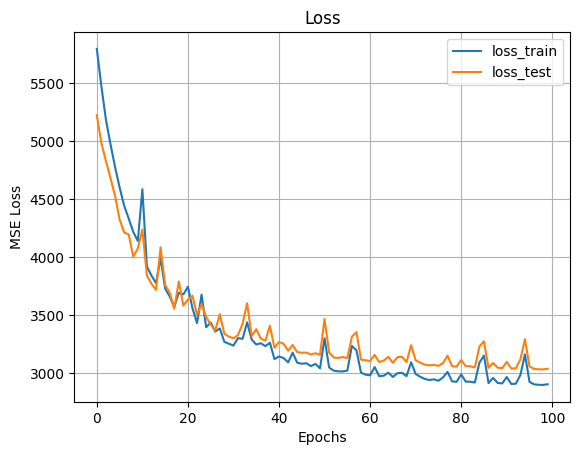

In [27]:
###################################
# MINI BATCH GRADIENT DESCENT     #
###################################

betas_mini, loss_train_history_mini, loss_test_history_mini =  mini_batch_gradient_descent(X_train, y_train,
                                                                            X_test, y_test, 
                                                                            learning_rate = 0.2, 
                                                                            n_epochs=100, 
                                                                            batch_size=16)

###################################
# LET'S VISUALIZE IT              #
###################################


plt.plot(loss_train_history_mini, label="loss_train")
plt.plot(loss_test_history_mini, label="loss_test")

# Set title and labels
plt.title('Loss')
plt.ylabel('MSE Loss')
plt.xlabel('Epochs')
plt.grid()
plt.legend()
plt.show()

## 🕵🏻‍♂️ Comparisons with Sklearn

In [28]:
X_train.head(3)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,fake
271,0.038076,0.050680,0.008883,0.042529,-0.042848,-0.021042,-0.039719,-0.002592,-0.018114,0.007207,1
290,0.059871,0.050680,0.076786,0.025315,0.001183,0.016849,-0.054446,0.034309,0.029935,0.044485,1
135,-0.005515,-0.044642,0.056307,-0.036656,-0.048351,-0.042963,-0.072854,0.037999,0.050782,0.056912,1


In [29]:
model = LinearRegression()
model.fit(X_train.drop(columns=["fake"]), y_train)
betas_sklearn = pd.DataFrame(np.hstack((model.coef_, model.intercept_)))
betas_sklearn.index = [f"beta{i}" for i in range(1, X_train.shape[1])]+["beta0"]
betas_sklearn.columns = ["betas_sklearn"]
betas_sklearn

,betas_sklearn
beta1,47.929655
beta2,-272.875985
beta3,503.419882
beta4,351.560497
beta5,-1035.698350
beta6,661.888674
beta7,215.616082
beta8,221.392757
beta9,794.484913
beta10,111.949077


In [33]:
betas_gradient_descent = pd.DataFrame(betas)
betas_gradient_descent.index = [f"beta{i}" for i in range(1, X_train.shape[1])]+["beta0"]
betas_gradient_descent.columns = ["betas_gradient_descent"]

In [35]:
betas_mini = pd.DataFrame(betas_mini)
betas_mini.index = [f"beta{i}" for i in range(1, X_train.shape[1])]+["beta0"]
betas_mini.columns = ["betas_mini"]

In [36]:
comparisons_beta = pd.concat([betas_sklearn, betas_gradient_descent, betas_mini], axis = 1)
comparisons_beta

,betas_sklearn,betas_gradient_descent,betas_mini
beta1,47.929655,1.503219,55.169391
beta2,-272.875985,0.332990,-196.789810
beta3,503.419882,4.458633,465.794870
beta4,351.560497,3.621831,315.525744
beta5,-1035.698350,1.303498,-42.901206
beta6,661.888674,1.031252,-92.567870
beta7,215.616082,-3.212669,-195.627149
beta8,221.392757,3.397549,126.075009
beta9,794.484913,4.375846,375.706254
beta10,111.949077,2.821687,158.351040


😳 The coefficients optimized through the Gradient Descent and Mini Batch Gradient descent are completely different from the coefficients obtained through an exact solution in Sklearn.

* When there is an analytical solution solving the equation $\nabla = [0 ... 0 ]$, we use it.
* When there are too many parameters to co-optimize, we use iterative methods (cf. Deep Learning)

## 🥡 Takeaways: a new Learning Curve to detect Underfitting / Overfitting 🔥🔥🔥

<img src="https://wagon-public-datasets.s3-eu-west-1.amazonaws.com/05-Machine-Learning/04-Under-the-Hood/underfitting_overfitting_at_a_glance.webp" width=800>